In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer

In [9]:
df=pd.read_csv('../titanic.csv',usecols=['Age','Fare','Survived'])
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [15]:
import matplotlib.pyplot as plt

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0
...,...,...,...
886,27.0,13.0000,0
887,19.0,30.0000,1
888,NaN,23.4500,0
889,26.0,30.0000,1


In [10]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [12]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [13]:
X=df[['Age','Fare']]
y=df['Survived']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


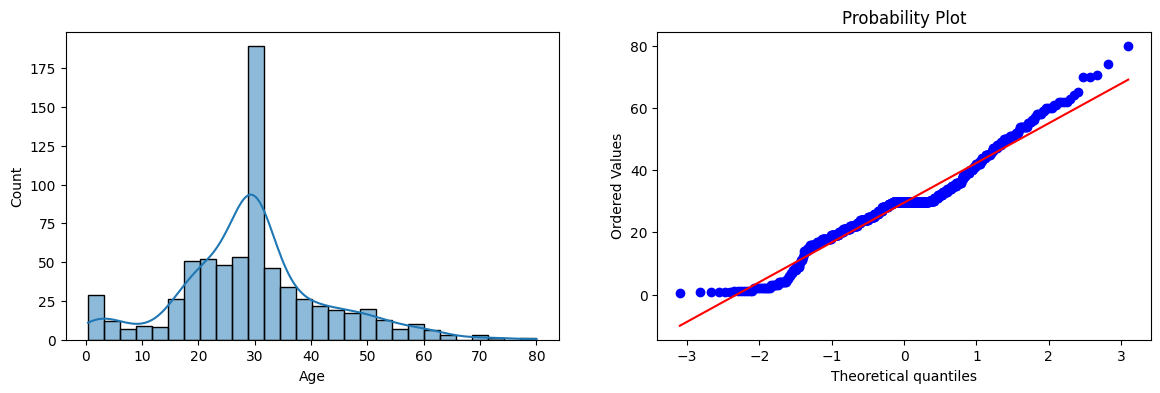

In [20]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
sns.histplot(X_train['Age'],kde=True)
plt.subplot(1,2,2)
stats.probplot(X_train['Age'],dist='norm',plot=plt)

plt.show()

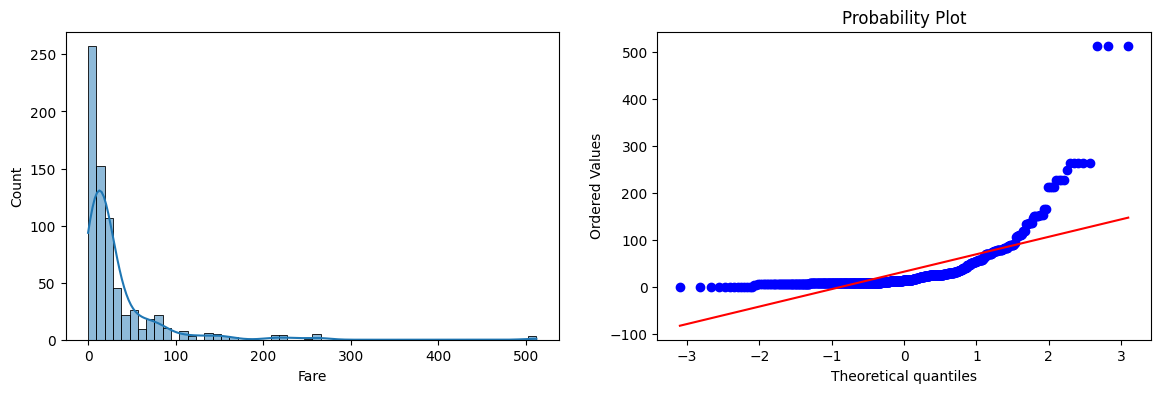

In [22]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
sns.histplot(X_train['Fare'],kde=True)
plt.subplot(1,2,2)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)

plt.show()

In [23]:
trf=FunctionTransformer(func=np.log1p)

In [24]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.fit_transform(X_test)

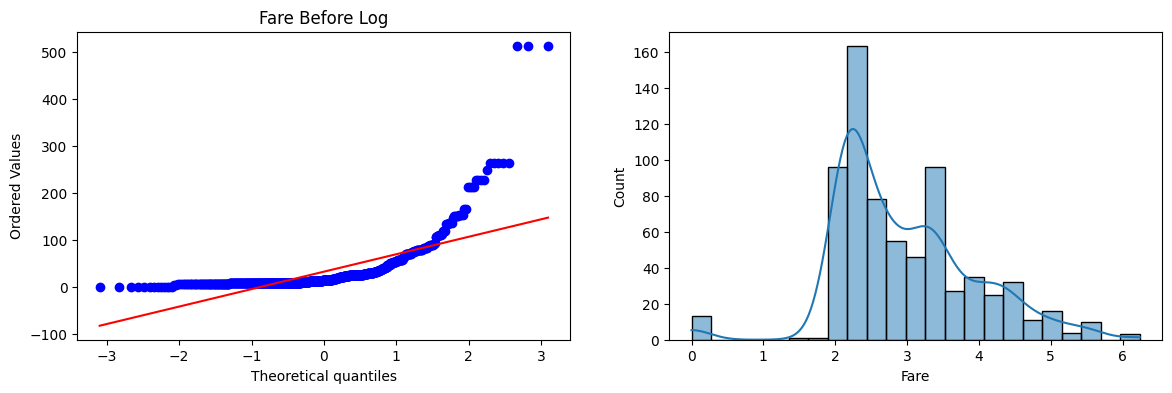

In [ ]:
# comparing the QQ plot of fare before and after log transform
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare Before Log')

plt.subplot(1,2,2)
stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
plt.title('Fare After Log')



plt.show()

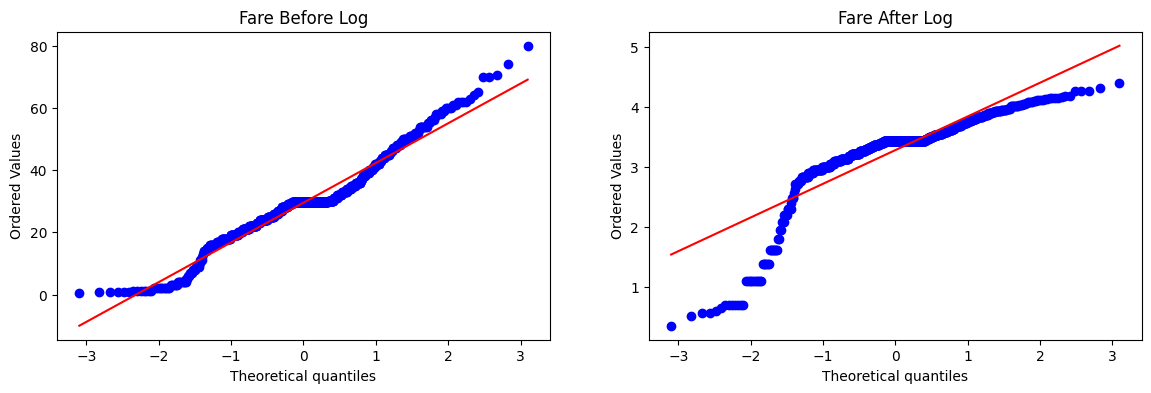

In [ ]:
# comparing the QQ plot of age before and after log transform
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Fare Before Log')

plt.subplot(1,2,2)
stats.probplot(X_train_transformed['Age'],dist='norm',plot=plt)
plt.title('Fare After Log')

plt.show()